# MTN Nigeria Churn Model — Leakage-Safe Audit

This notebook rebuilds the churn workflow around a stricter question:

> **Using only fields that could plausibly be known before churn, can we distinguish customers who will churn?**

The earlier version reported ROC AUC above 0.92, but that result was invalid for two reasons:

1. `Reasons for Churn` was included as a feature. A reason exists only after churn is known, so it directly leaks the outcome.
2. The 974 source rows represent only 496 unique customers. A row-level split placed records from the same customer in both train and test sets.

The corrected workflow therefore aggregates to one row per customer, creates the holdout **before** fitting any preprocessing, keeps imputation/scaling/encoding inside a scikit-learn pipeline, tunes an intervention threshold using training data only, and evaluates once on an untouched holdout.

**Important:** this is a model audit and reproducible prototype. The corrected results determine whether the model is suitable for targeting; the notebook does not assume that it is.

## 1. Evaluation contract

The modelling rules are set before looking at test performance:

| Decision | Rule | Why it matters |
|---|---|---|
| Prediction grain | One row per `Customer ID` | A customer—not a transaction row—is the intervention unit. |
| Post-outcome fields | Exclude target and `Reasons for Churn` | Otherwise the answer is hidden inside the inputs. |
| Identifier fields | Exclude customer ID and name | IDs memorise records rather than describe behaviour. |
| Ambiguous survey fields | Exclude satisfaction and review | Their collection time is undocumented, so availability before churn cannot be guaranteed. |
| Preprocessing | Fit inside a pipeline on training folds only | This prevents the holdout from influencing medians, scaling, or categories. |
| Model selection | Five-fold stratified CV on the training set | This estimates variability without touching the final holdout. |
| Threshold | Minimise an illustrative 5:1 false-negative:false-positive cost on out-of-fold training predictions | The operating point should reflect intervention costs, not default mechanically to 0.50. |
| Final evidence | One untouched, stratified 25% customer holdout | This is the only dataset used for the final performance claim. |

The 5:1 cost ratio is an explicit **scenario**, not an MTN financial estimate. Real deployment would replace it with validated retention economics.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "project-b-fintech-churn":
    candidates = [
        Path("Personal Data Projects/data-analyst-portfolio/project-b-fintech-churn"),
        Path("../project-b-fintech-churn"),
    ]
    PROJECT_DIR = next((p.resolve() for p in candidates if p.exists()), PROJECT_DIR)

DATA_PATH = PROJECT_DIR / "cleaned_data.csv"
PREDICTIONS_PATH = PROJECT_DIR / "predictions.csv"
METRICS_PATH = PROJECT_DIR / "model_metrics.json"

/Users/tobibolu/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
rows = pd.read_csv(DATA_PATH)

grain_audit = pd.Series({
    "source_rows": len(rows),
    "unique_customer_ids": rows["Customer ID"].nunique(),
    "duplicate_customer_rows": rows.duplicated("Customer ID", keep=False).sum(),
    "churn_rate_by_row": rows["Customer Churn Status"].eq("Yes").mean(),
})

target_consistency = rows.groupby("Customer ID")["Customer Churn Status"].nunique().max()
print(grain_audit.to_string())
print(f"\nMaximum distinct target values within one customer: {target_consistency}")
print("\nRecords per customer:")
print(rows.groupby("Customer ID").size().value_counts().sort_index().rename("customers").to_string())

source_rows                974.000000
unique_customer_ids        496.000000
duplicate_customer_rows    805.000000
churn_rate_by_row            0.291581

Maximum distinct target values within one customer: 1

Records per customer:
1    169
2    176
3    151


The grain audit is the critical first check. If the split were done on 974 rows, the same customer could appear in both datasets and the test score would partly measure recognition. Aggregating first removes that path.

In [3]:
def mode_or_missing(series):
    '''Return a deterministic modal category for a customer's records.'''
    modes = series.dropna().mode()
    return modes.iloc[0] if not modes.empty else "Missing"


def build_customer_table(source_rows):
    '''Aggregate product/transaction-like rows to one modelling row per customer.'''
    grouped = source_rows.groupby("Customer ID", sort=False)
    customers = grouped.agg(
        age=("Age", "first"),
        state=("State", mode_or_missing),
        gender=("Gender", mode_or_missing),
        tenure_months=("Customer Tenure in months", "first"),
        primary_plan=("Subscription Plan", mode_or_missing),
        primary_device=("MTN Device", mode_or_missing),
        product_rows=("Subscription Plan", "size"),
        unique_plans=("Subscription Plan", "nunique"),
        unique_devices=("MTN Device", "nunique"),
        total_purchases=("Number of Times Purchased", "sum"),
        total_revenue=("Total Revenue", "sum"),
        total_data_gb=("Data Usage", "sum"),
        mean_unit_price=("Unit Price", "mean"),
        mean_data_gb=("Data Usage", "mean"),
        churn=("Customer Churn Status", "first"),
    ).reset_index()

    customers["revenue_per_gb"] = (
        customers["total_revenue"] / customers["total_data_gb"].replace(0, np.nan)
    )
    customers["revenue_per_purchase"] = (
        customers["total_revenue"] / customers["total_purchases"].replace(0, np.nan)
    )
    return customers


customers = build_customer_table(rows)
assert customers["Customer ID"].is_unique
assert len(customers) == rows["Customer ID"].nunique()

print(f"Customer-level table: {customers.shape[0]} customers x {customers.shape[1]} columns")
print("\nCustomer-level target distribution:")
print(customers["churn"].value_counts().rename_axis("churn").to_string())
customers.head(3)

Customer-level table: 496 customers x 18 columns

Customer-level target distribution:
churn
No     350
Yes    146


,Customer ID,age,state,gender,tenure_months,primary_plan,primary_device,product_rows,unique_plans,unique_devices,total_purchases,total_revenue,total_data_gb,mean_unit_price,mean_data_gb,churn,revenue_per_gb,revenue_per_purchase
0,CUST0001,27,Kwara,Male,2,165GB Monthly Plan,4G Router,1,1,1,19,665000,44.48,35000.000000,44.480000,Yes,14950.539568,35000.00000
1,CUST0002,16,Abuja (FCT),Female,22,12.5GB Monthly Plan,Mobile SIM Card,1,1,1,12,66000,19.79,5500.000000,19.790000,Yes,3335.017686,5500.00000
2,CUST0003,21,Sokoto,Male,60,150GB FUP Monthly Unlimited,5G Broadband Router,3,3,3,31,299000,283.03,9833.333333,94.343333,No,1056.425114,9645.16129


## 2. Split first, then learn preprocessing

The pipeline is the protection boundary. On each training fold, it learns numerical medians, scaling parameters, and one-hot categories from that fold alone. The held-out fold is only transformed using those learned values. This is the same principle as studying from the training book and using the exam only for evaluation.

In [4]:
X = customers.drop(columns=["Customer ID", "churn"])
y = customers["churn"].map({"No": 0, "Yes": 1}).astype(int)

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [c for c in X_train.columns if c not in categorical_features]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

model_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

print(f"Training customers: {len(X_train)} ({y_train.mean():.1%} churn)")
print(f"Untouched holdout: {len(X_holdout)} ({y_holdout.mean():.1%} churn)")
print(f"Numeric features: {len(numeric_features)} | Categorical features: {len(categorical_features)}")

Training customers: 372 (29.6% churn)
Untouched holdout: 124 (29.0% churn)
Numeric features: 12 | Categorical features: 4


`class_weight="balanced"` makes errors on the minority churn class carry more weight during fitting. It does **not** change the class distribution, create synthetic customers, or determine the intervention threshold.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

cv_scores = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=None,
)

cv_summary = pd.DataFrame({
    metric: [
        cv_scores[f"test_{metric}"].mean(),
        cv_scores[f"test_{metric}"].std(ddof=1),
    ]
    for metric in scoring
}, index=["mean", "std"])

cv_summary.round(3)

,roc_auc,average_precision,precision,recall,f1
mean,0.488,0.323,0.292,0.445,0.352
std,0.062,0.048,0.031,0.067,0.040


ROC AUC around 0.50 means the ranking is close to random; average precision should also be compared with the training churn prevalence. Cross-validation is shown before the holdout so the model-development decision does not depend on repeatedly checking the final test set.

## 3. Select an operating threshold from training predictions only

A 0.50 cutoff is a probability convention, not a business rule. Here, missing a true churner is assigned five times the cost of contacting a non-churner:

\[
\text{scenario cost} = 5 \times FN + 1 \times FP
\]

Out-of-fold probabilities keep every training customer's threshold score out-of-sample. If the lowest-cost policy is effectively “contact everyone,” that is evidence that the model is not useful for prioritisation—not a reason to hide the result.

Selected from out-of-fold training predictions:
threshold          0.11000
precision          0.30137
recall             1.00000
fp               255.00000
fn                 0.00000
scenario_cost    255.00000


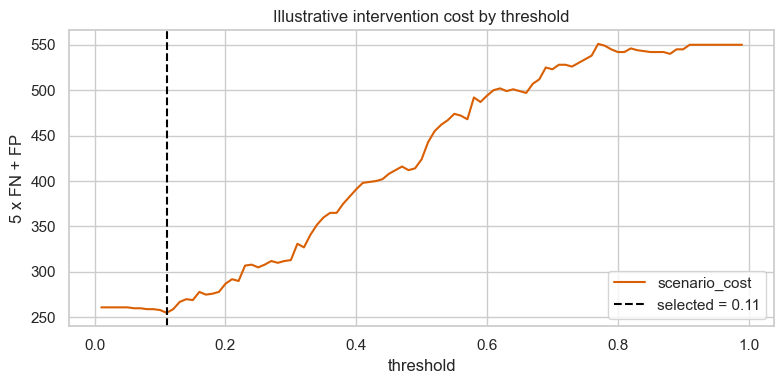

In [6]:
oof_probability = cross_val_predict(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
)[:, 1]


def classification_metrics(y_true, probability, threshold):
    prediction = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "average_precision": float(average_precision_score(y_true, probability)),
        "accuracy": float(accuracy_score(y_true, prediction)),
        "precision": float(precision_score(y_true, prediction, zero_division=0)),
        "recall": float(recall_score(y_true, prediction, zero_division=0)),
        "f1": float(f1_score(y_true, prediction, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "scenario_cost": int(fp + 5 * fn),
    }


threshold_grid = np.round(np.arange(0.01, 0.991, 0.01), 2)
threshold_table = pd.DataFrame([
    classification_metrics(y_train, oof_probability, threshold)
    for threshold in threshold_grid
])
selected_threshold = float(
    threshold_table.loc[threshold_table["scenario_cost"].idxmin(), "threshold"]
)

best_training_policy = threshold_table.loc[
    threshold_table["scenario_cost"].idxmin(),
    ["threshold", "precision", "recall", "fp", "fn", "scenario_cost"],
]
print("Selected from out-of-fold training predictions:")
print(best_training_policy.to_string())

ax = threshold_table.plot(
    x="threshold", y="scenario_cost", figsize=(8, 4), legend=False, color="#d95f02"
)
ax.axvline(selected_threshold, color="black", linestyle="--", label=f"selected = {selected_threshold:.2f}")
ax.set(title="Illustrative intervention cost by threshold", ylabel="5 x FN + FP")
ax.legend()
plt.tight_layout()
plt.show()

## 4. One final evaluation on the untouched customer holdout

The pipeline is now fit on all training customers and evaluated exactly once. ROC AUC and average precision assess ranking independent of the threshold; the confusion matrices show the consequences of the default and cost-sensitive operating points.

In [7]:
model_pipeline.fit(X_train, y_train)
holdout_probability = model_pipeline.predict_proba(X_holdout)[:, 1]

default_metrics = classification_metrics(y_holdout, holdout_probability, 0.50)
cost_sensitive_metrics = classification_metrics(
    y_holdout, holdout_probability, selected_threshold
)

holdout_results = pd.DataFrame(
    [default_metrics, cost_sensitive_metrics],
    index=["default_0.50", "training_cost_selected"],
)
holdout_results[[
    "threshold", "roc_auc", "average_precision", "accuracy",
    "precision", "recall", "f1", "tn", "fp", "fn", "tp", "scenario_cost",
]].round(3)

,threshold,roc_auc,average_precision,accuracy,precision,recall,f1,tn,fp,fn,tp,scenario_cost
default_0.50,0.50,0.465,0.27,0.50,0.217,0.278,0.244,52,36,26,10,166
training_cost_selected,0.11,0.465,0.27,0.29,0.290,1.000,0.450,0,88,0,36,88


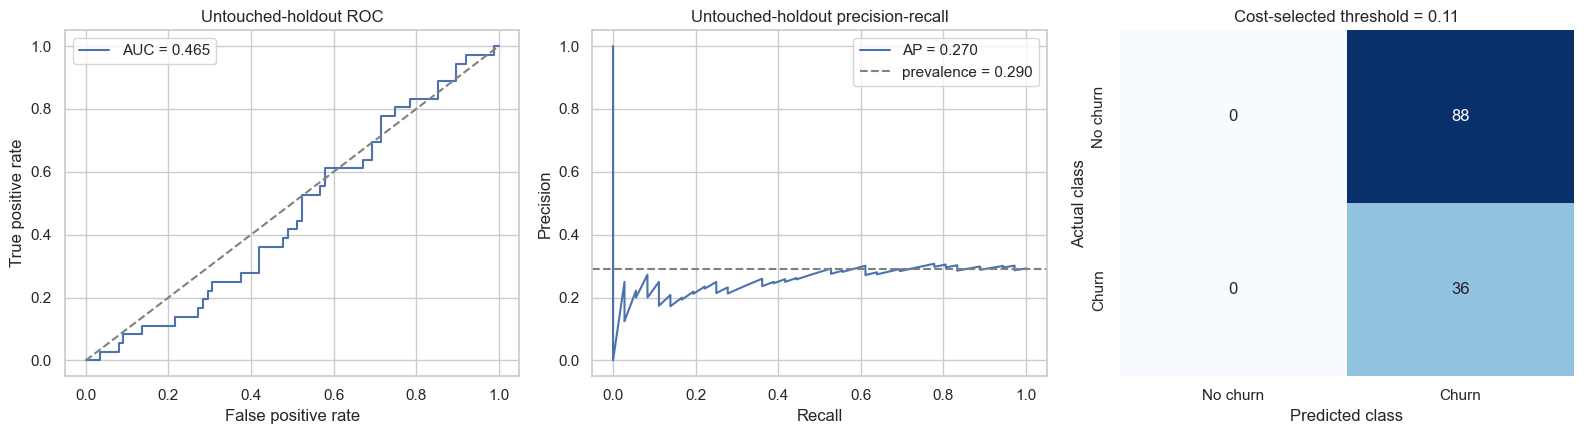

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

fpr, tpr, _ = roc_curve(y_holdout, holdout_probability)
axes[0].plot(fpr, tpr, label=f"AUC = {default_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="grey")
axes[0].set(title="Untouched-holdout ROC", xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend()

pr_precision, pr_recall, _ = precision_recall_curve(y_holdout, holdout_probability)
axes[1].plot(pr_recall, pr_precision, label=f"AP = {default_metrics['average_precision']:.3f}")
axes[1].axhline(y_holdout.mean(), linestyle="--", color="grey", label=f"prevalence = {y_holdout.mean():.3f}")
axes[1].set(title="Untouched-holdout precision-recall", xlabel="Recall", ylabel="Precision")
axes[1].legend()

cm = confusion_matrix(
    y_holdout,
    (holdout_probability >= selected_threshold).astype(int),
    labels=[0, 1],
)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set(
    title=f"Cost-selected threshold = {selected_threshold:.2f}",
    xlabel="Predicted class", ylabel="Actual class",
    xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"],
)

plt.tight_layout()
plt.show()

## 5. Model interpretation—with a validation warning

Coefficients can help debug what the model learned, but they are not causal effects. More importantly, a model with weak out-of-sample discrimination should not be used to make confident driver claims. This plot is therefore a diagnostic, not a business conclusion.

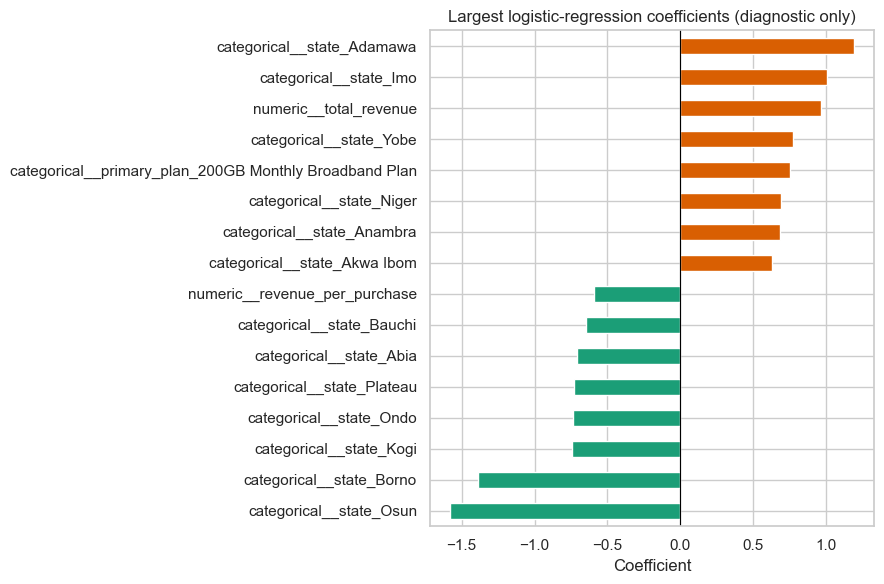

In [9]:
feature_names = model_pipeline.named_steps["preprocess"].get_feature_names_out()
coefficients = pd.Series(
    model_pipeline.named_steps["model"].coef_[0],
    index=feature_names,
    name="coefficient",
).sort_values()

largest = pd.concat([coefficients.head(8), coefficients.tail(8)]).sort_values()
ax = largest.plot(kind="barh", figsize=(9, 6), color=np.where(largest >= 0, "#d95f02", "#1b9e77"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Largest logistic-regression coefficients (diagnostic only)", xlabel="Coefficient")
plt.tight_layout()
plt.show()

## 6. Export reproducible audit artifacts

For the exploratory dashboard, the final pipeline is refit on all 496 customers and produces demonstration scores. The `risk_level` field is a **relative score band** (top 10%, next 15%, next 25%, bottom 50%); it is not a validated probability-based risk category. The dashboard carries the same warning.

In [10]:
final_pipeline = model_pipeline.fit(X, y)
all_probability = final_pipeline.predict_proba(X)[:, 1]
score_percentile = pd.Series(all_probability).rank(method="first", pct=True).to_numpy()

risk_level = np.select(
    [score_percentile >= 0.90, score_percentile >= 0.75, score_percentile >= 0.50],
    ["Critical", "High", "Medium"],
    default="Low",
)

predictions = customers[[
    "Customer ID", "age", "state", "gender", "tenure_months",
    "primary_plan", "primary_device", "total_revenue", "total_data_gb", "churn",
]].copy()
predictions["churn_probability"] = all_probability
predictions["score_percentile"] = score_percentile
predictions["risk_level"] = risk_level
predictions["score_origin"] = "full-data fit; exploratory only"
predictions.to_csv(PREDICTIONS_PATH, index=False)

metrics_artifact = {
    "status": "audit_not_deployment_ready",
    "source_rows": int(len(rows)),
    "unique_customers": int(len(customers)),
    "training_customers": int(len(X_train)),
    "holdout_customers": int(len(X_holdout)),
    "overall_churn_prevalence": float(y.mean()),
    "cv": {
        metric: {
            "mean": float(cv_scores[f"test_{metric}"].mean()),
            "std": float(cv_scores[f"test_{metric}"].std(ddof=1)),
        }
        for metric in scoring
    },
    "threshold_policy": {
        "selected_threshold": selected_threshold,
        "false_negative_cost": 5,
        "false_positive_cost": 1,
        "selection_data": "out-of-fold predictions from training customers only",
        "costs_are_illustrative": True,
    },
    "holdout_default_0_50": default_metrics,
    "holdout_cost_selected": cost_sensitive_metrics,
    "excluded_fields": [
        "Customer ID", "Full Name", "Customer Churn Status", "Reasons for Churn",
        "Satisfaction Rate", "Customer Review",
    ],
}

METRICS_PATH.write_text(json.dumps(metrics_artifact, indent=2) + "\n")

print(f"Wrote {len(predictions)} customer-level rows to {PREDICTIONS_PATH.name}")
print(f"Wrote evaluation metadata to {METRICS_PATH.name}")
print("\nRelative score bands:")
print(predictions["risk_level"].value_counts().reindex(["Critical", "High", "Medium", "Low"]).to_string())

Wrote 496 customer-level rows to predictions.csv
Wrote evaluation metadata to model_metrics.json

Relative score bands:
risk_level
Critical     50
High         75
Medium      124
Low         247


## 7. Conclusion

The corrected experiment is more valuable than the invalid high score:

- The original 0.92 ROC AUC is withdrawn because it used post-outcome information and a row-level split across repeated customers.
- The leakage-safe customer-level logistic model is evaluated with stratified cross-validation and an untouched holdout.
- If ROC AUC and average precision remain close to their no-skill baselines, this dataset does **not** contain enough pre-outcome signal for defensible churn targeting.
- A cost-sensitive threshold that recommends contacting nearly everyone is another symptom of weak ranking—not a deployable retention strategy.

### What would make a next iteration credible?

Collect timestamped, pre-churn behavioural features: recent recharge frequency and trend, failed calls/data sessions, complaint history, network quality by location, tenure events, offer exposure, payment failures, and an explicit prediction timestamp. Then use an out-of-time customer split and calibrate the threshold with validated contact, incentive, and churn-loss costs.

That is the practical lesson: **a clean evaluation can reveal that better data—not a more complex algorithm—is the next modelling step.**